# CODIGO DE ENTRENAMIENTO

In [46]:
#  Entrenamiento únicamente 
# ============================================================
import pandas as pd
import numpy as np
import joblib
import re

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
from nltk.corpus import stopwords

In [47]:
# Descargar recursos de NLTK
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dacma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dacma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
# Cargar modelo de spaCy en español
def cargar_modelo_spacy_es():
    for model_name in ("es_core_news_md", "es_core_news_sm"):
        try:
            print(f"Cargando modelo spaCy: {model_name}")
            return spacy.load(model_name)
        except OSError:
            continue

    print("No se encontro un modelo de spaCy en espanol instalado. Se usara un pipeline basico.")
    return spacy.blank("es")


nlp = cargar_modelo_spacy_es()

print("✅ Librerías cargadas correctamente.")

Cargando modelo spaCy: es_core_news_md
✅ Librerías cargadas correctamente.


# 1. CARGA DE DATOS

In [45]:
df = pd.read_excel("submuestreo_manual.xlsx", sheet_name="Datos_submuestreo")

print("=== Vista previa del dataset ===")
print(df.head())
print(f"\nForma del dataset: {df.shape}")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")

=== Vista previa del dataset ===
                                            Consulta  \
0                                 No se cuando entro   
1  Me ha llegado un correo sobre el certificado e...   
2  Calendario y proceso de inscripción al posgrad...   
3  Buenas tardes\nQuería preguntar por las citas ...   
4  Ya terminé mis materias de pregrado y necesito...   

                    Categoria_Manual  
0               Calendario académico  
1                  Gestión Económica  
2               Calendario académico  
3                  Gestión Académica  
4  Actualización de datos personales  

Forma del dataset: (769, 2)

Columnas disponibles:
['Consulta', 'Categoria_Manual']


# 2. PREPROCESAMIENTO DE TEXTO

In [48]:
STOPWORDS_ES = set(stopwords.words("spanish"))

# Stopwords adicionales específicas del dominio universitario
STOPWORDS_EXTRA = {
    "universidad", "nacional", "colombia", "unal", "sede", "bogotá",
    "favor", "gracias", "buenas", "buenos", "días", "tardes", "noches",
    "cordial", "saludo", "atentamente", "amablemente", "presente",
    "correo", "motivo", "solicito", "solicitud", "quisiera", "quiero",
    "necesito", "requiero", "agradezco", "agradecería", "muchas",
    "manera", "forma", "caso", "parte", "vez", "día", "semestre",
    "periodo", "académico", "estudiante", "programa", "curricular",
    "sia", "dninfoa", "portal", "plataforma", "sistema",
}

STOPWORDS_COMPLETO = STOPWORDS_ES.union(STOPWORDS_EXTRA)


def limpiar_texto(texto: str) -> str:
    """Limpieza básica: minúsculas, eliminar caracteres especiales y números."""
    texto = str(texto).lower()
    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    # Eliminar correos electrónicos
    texto = re.sub(r"\S+@\S+", " ", texto)
    # Eliminar números y caracteres especiales, conservar letras y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def eliminar_stopwords(texto: str) -> str:
    """Elimina stopwords del texto."""
    tokens = texto.split()
    tokens_filtrados = [t for t in tokens if t not in STOPWORDS_COMPLETO and len(t) > 2]
    return " ".join(tokens_filtrados)


def lematizar(texto: str) -> str:
    """Lematiza el texto usando spaCy."""
    doc = nlp(texto)
    lemas = [
        token.lemma_ if token.lemma_ else token.text
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.lemma_ if token.lemma_ else token.text) > 2
    ]
    return " ".join(lemas)


def preprocesar(texto: str) -> str:
    """Pipeline completo: limpieza → stopwords → lematización."""
    texto = limpiar_texto(texto)
    texto = eliminar_stopwords(texto)
    texto = lematizar(texto)
    return texto

In [49]:
print("\n⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...")
df["Consulta_Procesada"] = df["Consulta"].apply(preprocesar)
df["Categoria_Manual"] = df["Categoria_Manual"].str.strip()
# Eliminar filas sin texto o sin etiqueta
df = df.dropna(subset=["Consulta", "Categoria_Manual"])
df = df[df["Consulta"] != ""]

print("✅ Preprocesamiento completado.")
print("\nEjemplo de transformación:")
print(f"  ORIGINAL : {df['Consulta'].iloc[0][:100]}...")
print(f"  PROCESADO: {df['Consulta_Procesada'].iloc[0][:100]}...")
print(f"\n=== Distribución de categorías (ENTRENAMIENTO COMPLETO) ===")
print(df["Categoria_Manual"].value_counts())
print(f"\nTotal de muestras para entrenamiento: {len(df)}")


⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...
✅ Preprocesamiento completado.

Ejemplo de transformación:
  ORIGINAL : No se cuando entro...
  PROCESADO: entro...

=== Distribución de categorías (ENTRENAMIENTO COMPLETO) ===
Categoria_Manual
Gestión Económica                                    217
Gestión Académica                                    162
Carnetización                                         96
Información general sobre servicios estudiantiles     82
Calendario académico                                  61
Actualización de datos personales                     60
Certificados                                          36
Reubicación socioeconómica en Pregrado                34
Política de gratuidad (matrícula cero) Pregrado       21
Name: count, dtype: int64

Total de muestras para entrenamiento: 769


# 3. CODIFICACIÓN DE ETIQUETAS

In [50]:
le = LabelEncoder()
y = le.fit_transform(df["Categoria_Manual"])
X = df["Consulta"].values

print(f"\nClases identificadas ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    print(f"  [{i}] {cls}")


Clases identificadas (9):
  [0] Actualización de datos personales
  [1] Calendario académico
  [2] Carnetización
  [3] Certificados
  [4] Gestión Académica
  [5] Gestión Económica
  [6] Información general sobre servicios estudiantiles
  [7] Política de gratuidad (matrícula cero) Pregrado
  [8] Reubicación socioeconómica en Pregrado


# 4. PIPELINE: TF-IDF + SVM

In [51]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),       # unigramas y bigramas
        max_features=10000,       # vocabulario máximo
        sublinear_tf=True,        # escala logarítmica en TF
        min_df=2,                 # ignorar términos muy raros
        strip_accents="unicode",
        analyzer="word",
        token_pattern=r"[a-záéíóúüñ]{2,}"  # solo palabras en español
    )),
    ("svm", SVC(
        kernel="linear",          # lineal: mejor para texto
        C=1.0,                    # parámetro de regularización
        probability=True,         # habilitar predict_proba
        class_weight="balanced",  # manejo de clases desbalanceadas
        random_state=42
    ))
])

# 5. ENTRENAMIENTO CON TODOS LOS DATOS

In [52]:
print("\n⏳ Entrenando modelo SVM con todos los datos...")

X_fit = np.asarray(X, dtype=str)
y_fit = np.asarray(y, dtype=np.int64)

pipeline.fit(X_fit, y_fit)
print("✅ Entrenamiento completado.")


⏳ Entrenando modelo SVM con todos los datos...
✅ Entrenamiento completado.


# 6. MÉTRICAS SOBRE EL CONJUNTO DE ENTRENAMIENTO

In [53]:
y_pred_train = pipeline.predict(X)

print("\n=== Reporte sobre datos de ENTRENAMIENTO ===")
print(classification_report(
    y, y_pred_train,
    target_names=le.classes_,
    zero_division=0
))


=== Reporte sobre datos de ENTRENAMIENTO ===
                                                   precision    recall  f1-score   support

                Actualización de datos personales       0.98      1.00      0.99        60
                             Calendario académico       0.98      1.00      0.99        61
                                    Carnetización       1.00      1.00      1.00        96
                                     Certificados       1.00      1.00      1.00        36
                                Gestión Académica       0.98      0.98      0.98       162
                                Gestión Económica       1.00      0.97      0.98       217
Información general sobre servicios estudiantiles       0.99      1.00      0.99        82
  Política de gratuidad (matrícula cero) Pregrado       0.91      1.00      0.95        21
           Reubicación socioeconómica en Pregrado       0.97      1.00      0.99        34

                                         a

# 7. MATRIZ DE CONFUSIÓN (entrenamiento)

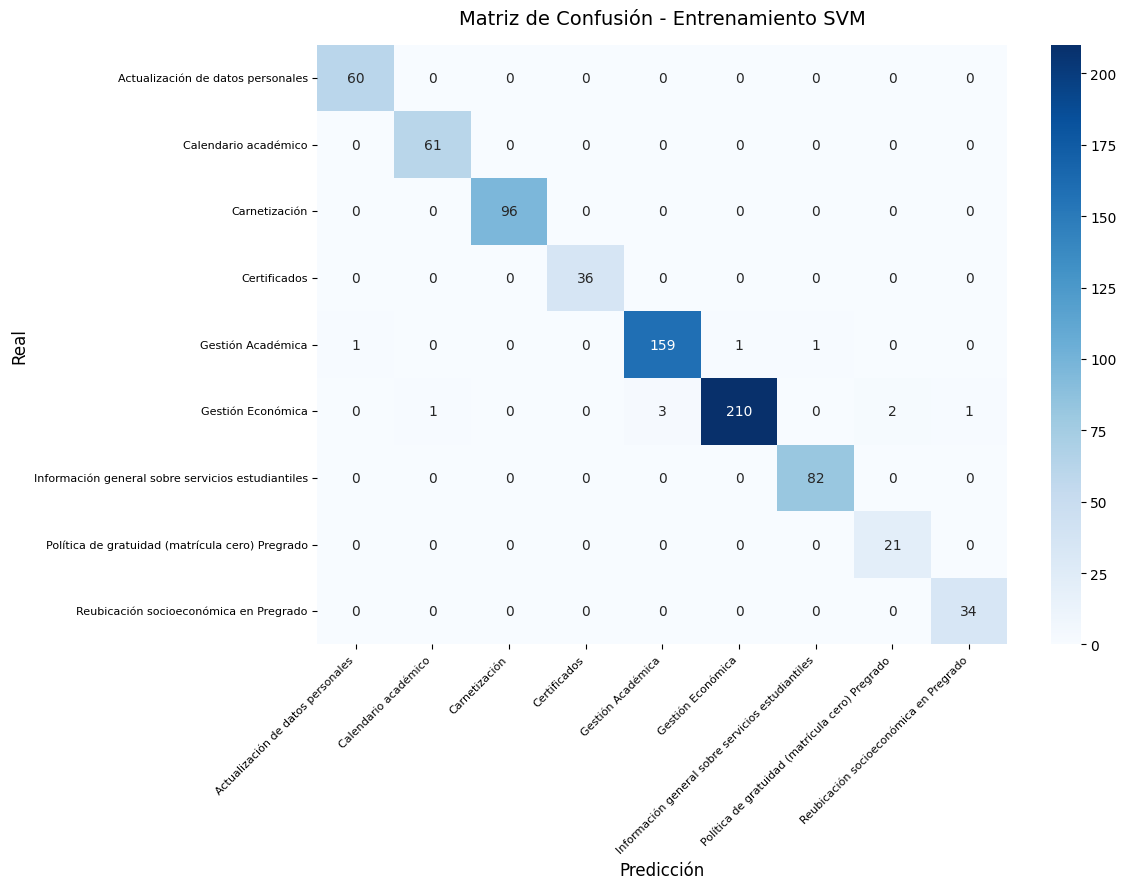

In [54]:
cm = confusion_matrix(y, y_pred_train)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_title("Matriz de Confusión - Entrenamiento SVM", fontsize=14, pad=15)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# 8. GUARDAR MODELO Y CODIFICADOR DE ETIQUETAS

In [55]:
joblib.dump(pipeline, "svm_model.pkl")
joblib.dump(le,       "label_encoder.pkl")
print("\n💾 Modelo guardado: svm_model.pkl")
print("💾 Codificador guardado: label_encoder.pkl")


💾 Modelo guardado: svm_model.pkl
💾 Codificador guardado: label_encoder.pkl


# 9. FUNCIÓN PARA USAR (TESTING)

In [56]:
def predict_category(texts: list, model_path="svm_model.pkl", encoder_path="label_encoder.pkl"):
    """
    Carga el modelo guardado y predice la categoría de nuevos textos.

    Uso:
        results = predict_category(["quiero saber mi fecha de inscripción"])
        print(results)
    """
    model   = joblib.load(model_path)
    encoder = joblib.load(encoder_path)

    texts_clean = [clean_text(t) for t in texts]
    preds_idx   = model.predict(texts_clean)
    preds_proba = model.predict_proba(texts_clean)

    results = []
    for i, text in enumerate(texts):
        results.append({
            "texto"      : text,
            "categoria"  : encoder.inverse_transform([preds_idx[i]])[0],
            "confianza"  : round(float(preds_proba[i].max()), 4)
        })
    return pd.DataFrame(results)

# 10. EJEMPLO DE USO

In [57]:
# Ejemplo rápido de predicción con el modelo recién entrenado
ejemplos = [
    "necesito saber cuándo es la semana de inducción para derecho",
    "error al subir el certificado electoral para el descuento",
    "quiero actualizar mi cédula de ciudadanía en el SIA",
    "no me aparece la cita de inscripción de asignaturas",
]
print("\n=== Ejemplo de predicción con el modelo entrenado ===")
print(predict_category(ejemplos).to_string(index=False))


=== Ejemplo de predicción con el modelo entrenado ===
                                                       texto                         categoria  confianza
necesito saber cuándo es la semana de inducción para derecho              Calendario académico     0.9725
   error al subir el certificado electoral para el descuento                 Gestión Económica     0.9996
         quiero actualizar mi cédula de ciudadanía en el SIA Actualización de datos personales     0.9739
         no me aparece la cita de inscripción de asignaturas                 Gestión Académica     0.9893


# 11. EVALUACIÓN CRUZADA CON DATA SET ORIGINAL (150 DATOS NUEVOS PARA LA PREDICICION)

In [58]:
df_new = pd.read_excel("data/Data_arreglada.xlsx")

print(f"\n=== Vista previa de Data_arreglada.xlsx ===")
print(df_new.head())
print(f"\nForma del dataset: {df_new.shape}")
print(f"\nColumnas disponibles:\n{df_new.columns.tolist()}")


=== Vista previa de Data_arreglada.xlsx ===
                                   Categoria  \
0                              Carnetización   
1                       Calendario académico   
2                              Carnetización   
3  ​ Gestión Económica - Información general   
4                              Carnetización   

  ¿Con la información que se le ha expuesto se ha resuelto su consulta?  \
0                                                 No                      
1                                                 No                      
2                                                 Sí                      
3                                                 Sí                      
4                                                 No                      

                                            Consulta  
0  Ayuda no se como inscribir asignaturas y nadie...  
1           Donde puedo ver el calendario académico?  
2                                                N

## Cruzar las dos bases para obtener los 150 datos nuevos

In [59]:
# Cruce por texto de consulta para identificar registros NUEVOS en df_new
df_new_work = df_new.copy()

# Normalizar texto de consulta en la nueva base
df_new_work["Consulta_limpia"] = df_new_work["Consulta"].apply(clean_text)

# Quitar consultas vacías/nulas
df_new_work = df_new_work[df_new_work["Consulta_limpia"] != ""].copy()

# Conjunto de consultas ya usadas en entrenamiento
consultas_train = set(df["Consulta"].astype(str))

# Filtrar solo consultas que NO estén en entrenamiento
df_nuevos = df_new_work[~df_new_work["Consulta_limpia"].isin(consultas_train)].copy()

# Quitar duplicados internos de la nueva base
df_nuevos = df_nuevos.drop_duplicates(subset=["Consulta_limpia"]).copy()

# Tomar 150 registros nuevos (muestra aleatoria reproducible)
n = min(150, len(df_nuevos))
df_150_nuevos = df_nuevos.sample(n=n, random_state=42).reset_index(drop=True)

print(f"Registros en df_new (con consulta válida): {len(df_new_work)}")
print(f"Registros nuevos vs entrenamiento: {len(df_nuevos)}")
print(f"Registros seleccionados: {len(df_150_nuevos)}")

# Vista previa
display(df_150_nuevos[["Categoria", "Consulta"]].head(10))

Registros en df_new (con consulta válida): 35161
Registros nuevos vs entrenamiento: 34838
Registros seleccionados: 150


,Categoria,Consulta
0,Gestión Económica - Información general,Hace poco enviaron un correo para el envio del...
1,Deseo por favor obtener una copia de mi recibo...,Deseo obtener una copia de mi recibo de matric...
2,REPORTE INCORRECTO DE CALIFICACIÓN,ASIGNATURA REPORTADA CON CALIFICACIÓN EN CERO ...
3,Gestión Económica - Información general,Reciban un cordial saludo.\n\nEl lugar donde t...
4,Matricula,"Buenas tardes,\n\nAgradezco mayor información ..."
5,Actualización de estado de egresado a estudian...,Ya ha pasado 1 semestre de la maestria y en si...
6,Re-ingreso,"No sé ha dado respuesta , ni la asesoría corre..."
7,Gestión Económica - Inconsistencias sobre recibo,Tengo un problema para pagar uno de los fracci...
8,"se me cancelo el semestre y no se el motivo, h...",Me permito informarles que mi semestre fue blo...
9,"Gestión Académica - Inscripción, adiciones y c...",Ingresé al programa de Filosofía el periodo 20...


## Guardar estos datos es para evaluación posterior

In [61]:
# Guardar los datos generados en un solo archivo Excel (múltiples hojas)
with pd.ExcelWriter("datos_anteriores.xlsx") as writer:
    df.to_excel(writer, sheet_name="entrenamiento_df", index=False)
    df_new.to_excel(writer, sheet_name="data_original_nueva", index=False)
    df_new_work.to_excel(writer, sheet_name="data_nueva_limpia", index=False)
    df_nuevos.to_excel(writer, sheet_name="registros_nuevos", index=False)
    df_150_nuevos.to_excel(writer, sheet_name="muestra_150_nuevos", index=False)

    # Matriz de confusión con etiquetas
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    cm_df.to_excel(writer, sheet_name="matriz_confusion", index=True)

print("✅ Archivo generado: datos_anteriores.xlsx")

✅ Archivo generado: datos_anteriores.xlsx


## PREDICCIÓN SOBRE LOS 150 DATOS NUEVOS

In [64]:
# Predicción de los 150 datos nuevos usando la función ya definida
resultados_150 = predict_category(df_150_nuevos["Consulta"].astype(str).tolist())

# Unir resultados con el dataframe original de 150
df_eval_150 = pd.concat(
    [df_150_nuevos.reset_index(drop=True), resultados_150[["categoria", "confianza"]]],
    axis=1
).rename(columns={
    "categoria": "Prediccion_modelo",
    "confianza": "Confianza_modelo"
})

print("✅ Predicción completada para 150 registros.")
display(df_eval_150.head(10))

✅ Predicción completada para 150 registros.


,Categoria,¿Con la información que se le ha expuesto se ha resuelto su consulta?,Consulta,Consulta_limpia,Prediccion_modelo,Confianza_modelo
0,Gestión Económica - Información general,No,Hace poco enviaron un correo para el envio del...,hace poco enviaron un correo para el envio del...,Gestión Económica,0.6712
1,Deseo por favor obtener una copia de mi recibo...,No,Deseo obtener una copia de mi recibo de matric...,deseo obtener una copia de mi recibo de matric...,Gestión Económica,0.7646
2,REPORTE INCORRECTO DE CALIFICACIÓN,No,ASIGNATURA REPORTADA CON CALIFICACIÓN EN CERO ...,asignatura reportada con calificación en cero ...,Gestión Académica,0.4509
3,Gestión Económica - Información general,No,Reciban un cordial saludo.\n\nEl lugar donde t...,reciban un cordial saludo el lugar donde traba...,Gestión Económica,0.8277
4,Matricula,No,"Buenas tardes,\n\nAgradezco mayor información ...",buenas tardes agradezco mayor información en r...,Gestión Económica,0.4390
5,Actualización de estado de egresado a estudian...,No,Ya ha pasado 1 semestre de la maestria y en si...,ya ha pasado semestre de la maestria y en sist...,Carnetización,0.4525
6,Re-ingreso,No,"No sé ha dado respuesta , ni la asesoría corre...",no sé ha dado respuesta ni la asesoría correct...,Gestión Académica,0.4947
7,Gestión Económica - Inconsistencias sobre recibo,No,Tengo un problema para pagar uno de los fracci...,tengo un problema para pagar uno de los fracci...,Gestión Económica,0.9918
8,"se me cancelo el semestre y no se el motivo, h...",No,Me permito informarles que mi semestre fue blo...,me permito informarles que mi semestre fue blo...,Gestión Académica,0.4273
9,"Gestión Académica - Inscripción, adiciones y c...",No,Ingresé al programa de Filosofía el periodo 20...,ingresé al programa de filosofía el periodo pe...,Gestión Académica,0.7748


## Guardar los datos de la predicción de 150

In [67]:
# Guardar la predicción de los 150 datos nuevos en un archivo Excel
df_eval_150.to_excel("prediccion_150_nuevos.xlsx", index=False)
print("✅ Predicciones guardadas en: prediccion_150_nuevos.xlsx")

✅ Predicciones guardadas en: prediccion_150_nuevos.xlsx


## METRICAS DE EVALUACIÓN

=== MÉTRICAS DE EVALUACIÓN - 150 DATOS ===
Total de registros en la muestra: 150
Registros con categoría homologada para evaluar: 150
Accuracy: 0.8200

=== Reporte de clasificación ===


,precision,recall,f1-score,support
Actualización de datos personales,1.000000,1.000000,1.000000,1.00
Aplazamiento de matrícula inicial,0.000000,0.000000,0.000000,3.00
Calendario académico,0.000000,0.000000,0.000000,0.00
Carnetización,0.750000,1.000000,0.857143,3.00
Certificados,0.666667,0.666667,0.666667,3.00
Gestión Académica,0.804878,0.804878,0.804878,41.00
Gestión Económica,0.900000,0.890110,0.895028,91.00
Información general sobre servicios estudiantiles,0.250000,1.000000,0.400000,2.00
Política de gratuidad (matrícula cero) Pregrado,0.000000,0.000000,0.000000,4.00
Reubicación socioeconómica en Pregrado,0.500000,0.500000,0.500000,2.00


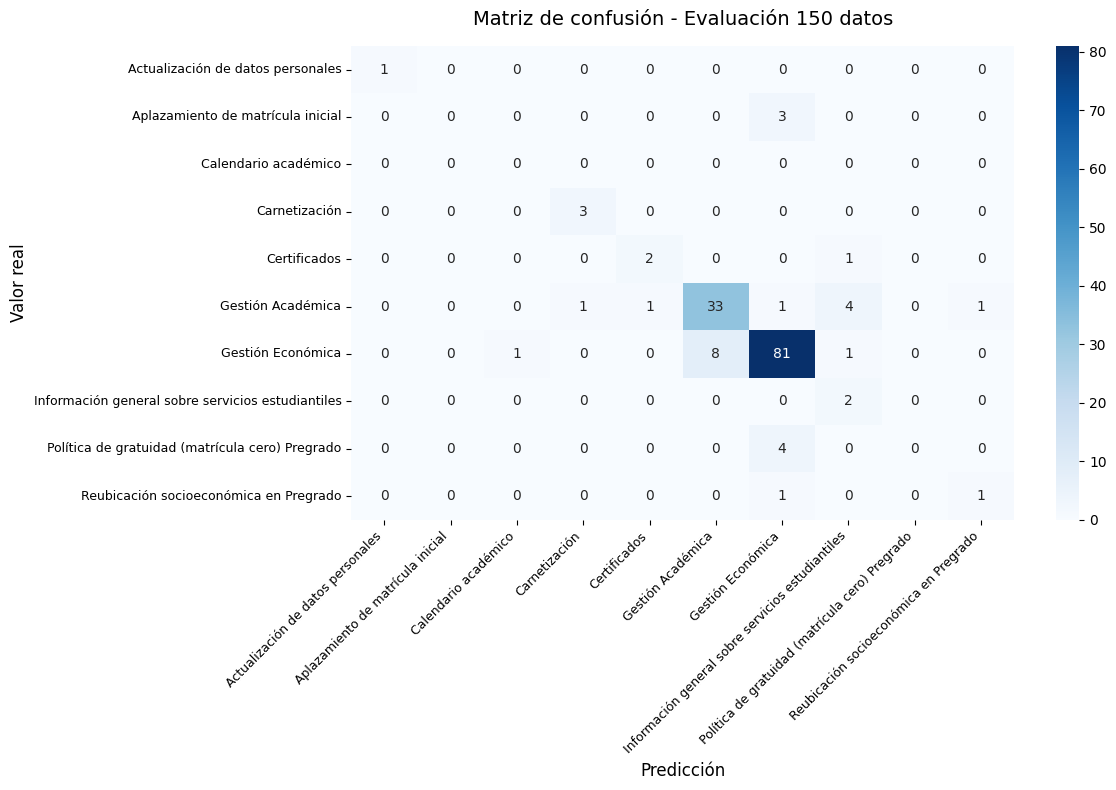

In [83]:
# Métricas de evaluación sobre los 150 datos nuevos
print("=== MÉTRICAS DE EVALUACIÓN - 150 DATOS ===")
print(f"Total de registros en la muestra: {len(df_eval_150)}")
print(f"Registros con categoría homologada para evaluar: {len(y_true_eval)}")

accuracy_150 = (y_true_eval.reset_index(drop=True) == y_pred_eval.reset_index(drop=True)).mean()
print(f"Accuracy: {accuracy_150:.4f}")

print("\n=== Reporte de clasificación ===")
display(reporte_df)

labels_eval = sorted(set(y_true_eval) | set(y_pred_eval))
cm_150 = confusion_matrix(y_true_eval, y_pred_eval, labels=labels_eval)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cm_150,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_eval,
    yticklabels=labels_eval,
    ax=ax
)
ax.set_title("Matriz de confusión - Evaluación 150 datos", fontsize=14, pad=15)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Valor real", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# 12. GUARDAR EL MODELO ENTRENADO (150 datos)

In [84]:
# Guardar el modelo entrenado y el codificador de etiquetas para los 150 datos
joblib.dump(pipeline, "svm_model_150.pkl")
joblib.dump(le,       "label_encoder_150.pkl")
print("💾 Modelo guardado: svm_model_150.pkl")
print("💾 Codificador guardado: label_encoder_150.pkl")

💾 Modelo guardado: svm_model_150.pkl
💾 Codificador guardado: label_encoder_150.pkl


## Comparacion de los datos entrenados con la validación manual

In [85]:
archivo_pred = "prediccion_150_nuevos.xlsx"
df_pred = pd.read_excel(archivo_pred)

def buscar_columna(df, candidatas):
    columnas_lower = {col.lower(): col for col in df.columns}
    for candidata in candidatas:
        if candidata.lower() in columnas_lower:
            return columnas_lower[candidata.lower()]
    return None

col_pred = buscar_columna(df_pred, ["Prediccion_modelo", "prediccion_modelo"])
col_manual = buscar_columna(df_pred, ["Categoria_Manual", "categoria_manual", "Categoria", "categoria"])

if col_pred is None or col_manual is None:
    raise ValueError(f"No se encontraron las columnas esperadas. Columnas disponibles: {df_pred.columns.tolist()}")

df_pred["Coincide_prediccion"] = (
    df_pred[col_pred].astype(str).str.strip().str.lower()
    == df_pred[col_manual].astype(str).str.strip().str.lower()
)

display(df_pred[[col_manual, col_pred, "Coincide_prediccion"]].head(20))

df_pred.to_excel("prediccion_150_nuevos_con_validacion.xlsx", index=False)
print("✅ Archivo guardado: prediccion_150_nuevos_con_validacion.xlsx")

,Categoria_Manual,Prediccion_modelo,Coincide_prediccion
0,Gestión Económica,Gestión Económica,True
1,Gestión Económica,Gestión Económica,True
2,Gestión Académica,Gestión Académica,True
3,Gestión Económica,Gestión Económica,True
4,Gestión Económica,Gestión Económica,True
5,Carnetización,Carnetización,True
6,Gestión Académica,Gestión Académica,True
7,Gestión Económica,Gestión Económica,True
8,Gestión Económica,Gestión Académica,False
9,Gestión Académica,Gestión Académica,True


✅ Archivo guardado: prediccion_150_nuevos_con_validacion.xlsx


C:\Users\dacma\AppData\Local\Temp\ipykernel_9724\1893396283.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


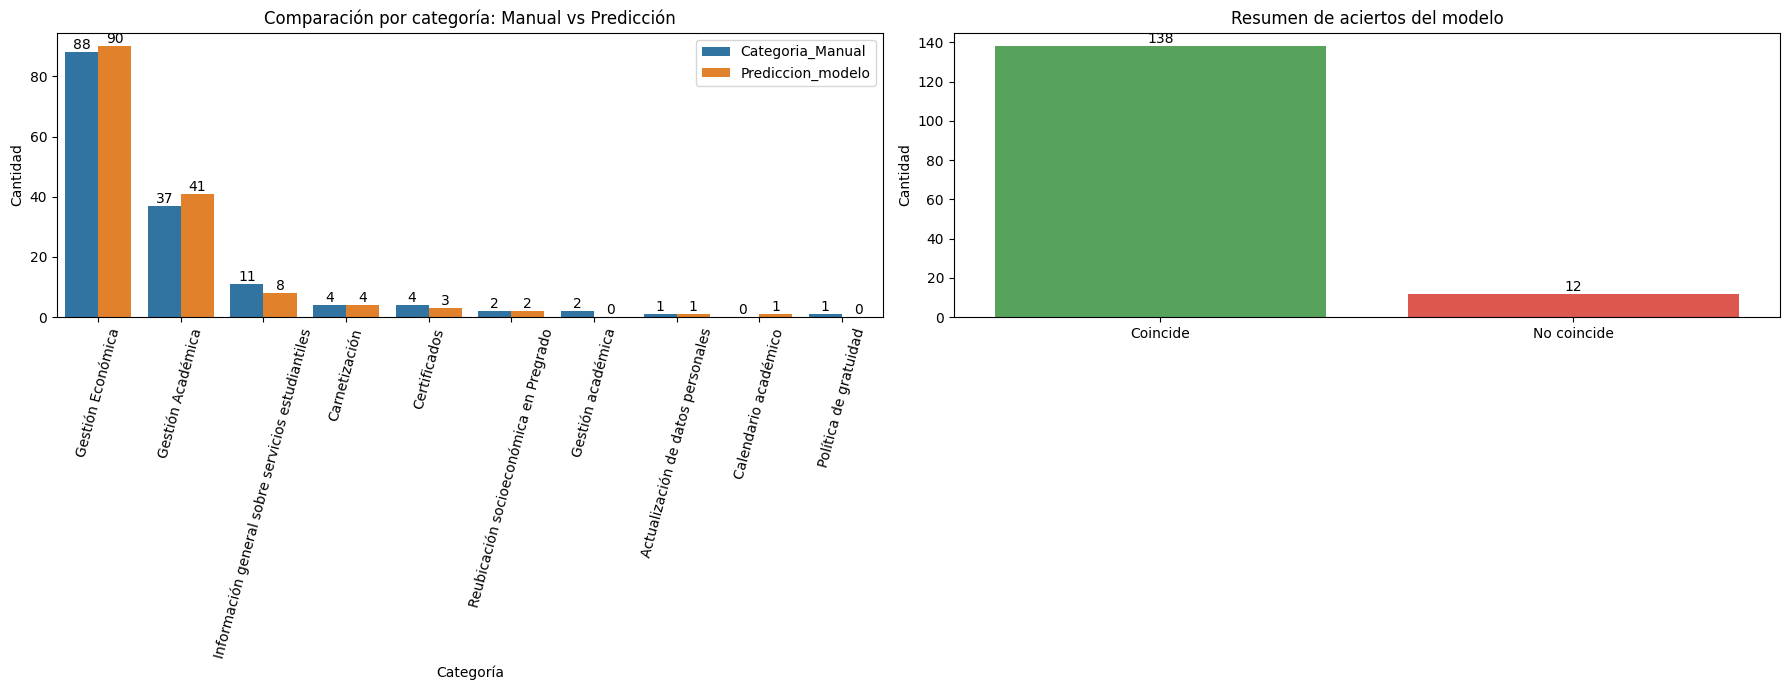

In [86]:
# Comparación entre categorías manuales y predichas
comparacion_categorias = pd.DataFrame({
    "Categoria_Manual": df_pred["Categoria_Manual"].value_counts(),
    "Prediccion_modelo": df_pred["Prediccion_modelo"].value_counts()
}).fillna(0)

comparacion_categorias["total"] = (
    comparacion_categorias["Categoria_Manual"] + comparacion_categorias["Prediccion_modelo"]
)
comparacion_categorias = comparacion_categorias.sort_values("total", ascending=False).drop(columns="total")

comparacion_plot = comparacion_categorias.reset_index().rename(columns={"index": "Categoria"})
comparacion_plot = comparacion_plot.melt(
    id_vars="Categoria",
    var_name="Tipo",
    value_name="Cantidad"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=comparacion_plot,
    x="Categoria",
    y="Cantidad",
    hue="Tipo",
    ax=axes[0]
)
axes[0].set_title("Comparación por categoría: Manual vs Predicción")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=75)
axes[0].legend(title="")

resumen_coincidencia = df_pred["Coincide_prediccion"].value_counts().rename({
    True: "Coincide",
    False: "No coincide"
}).reset_index()
resumen_coincidencia.columns = ["Resultado", "Cantidad"]

sns.barplot(
    data=resumen_coincidencia,
    x="Resultado",
    y="Cantidad",
    palette=["#4CAF50", "#F44336"],
    ax=axes[1]
)
axes[1].set_title("Resumen de aciertos del modelo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

In [87]:
# Estadísticas de desempeño y errores: Categoría manual vs predicción
columnas_requeridas = ["Categoria_Manual", "Prediccion_modelo", "Confianza_modelo"]
faltantes = [c for c in columnas_requeridas if c not in df_pred.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en df_pred: {faltantes}")

comp = df_pred.copy()

# Normalización ligera para comparación robusta
comp["manual_norm"] = comp["Categoria_Manual"].astype(str).str.strip()
comp["pred_norm"] = comp["Prediccion_modelo"].astype(str).str.strip()
comp["Es_error"] = comp["manual_norm"] != comp["pred_norm"]

# Métricas globales
total = len(comp)
errores = int(comp["Es_error"].sum())
aciertos = total - errores
accuracy = aciertos / total if total else 0.0
error_rate = errores / total if total else 0.0

estadisticas = pd.DataFrame({
    "Métrica": ["Total", "Aciertos", "Errores", "Accuracy", "Error rate"],
    "Valor": [total, aciertos, errores, round(accuracy, 4), round(error_rate, 4)]
})

print("=== Estadísticas generales ===")
display(estadisticas)

print("=== Reporte de clasificación ===")
print(classification_report(comp["manual_norm"], comp["pred_norm"], zero_division=0))

# Matriz de confusión
labels_cmp = sorted(set(comp["manual_norm"]) | set(comp["pred_norm"]))
cm_cmp = confusion_matrix(comp["manual_norm"], comp["pred_norm"], labels=labels_cmp)
cm_cmp_df = pd.DataFrame(cm_cmp, index=labels_cmp, columns=labels_cmp)

print("=== Matriz de confusión (manual vs predicción) ===")
display(cm_cmp_df)

# Desglose de errores
errores_detalle = comp[comp["Es_error"]].copy()
print(f"=== Total errores: {len(errores_detalle)} ===")

if len(errores_detalle) > 0:
    resumen_errores = (
        errores_detalle
        .groupby(["Categoria_Manual", "Prediccion_modelo"], dropna=False)
        .size()
        .reset_index(name="Cantidad")
        .sort_values("Cantidad", ascending=False)
    )

    print("=== Errores más frecuentes (manual -> predicción) ===")
    display(resumen_errores.head(20))

    print("=== Confianza del modelo ===")
    print(f"Promedio confianza en aciertos: {comp.loc[~comp['Es_error'], 'Confianza_modelo'].mean():.4f}")
    print(f"Promedio confianza en errores : {comp.loc[comp['Es_error'], 'Confianza_modelo'].mean():.4f}")

    print("=== Muestra de errores ===")
    display(
        errores_detalle[
            ["Categoria_Manual", "Prediccion_modelo", "Confianza_modelo", "Consulta"]
        ].head(15)
    )
else:
    print("No se encontraron errores en la comparación.")

=== Estadísticas generales ===


,Métrica,Valor
0,Total,150.00
1,Aciertos,138.00
2,Errores,12.00
3,Accuracy,0.92
4,Error rate,0.08


=== Reporte de clasificación ===
                                                   precision    recall  f1-score   support

                Actualización de datos personales       1.00      1.00      1.00         1
                             Calendario académico       0.00      0.00      0.00         0
                                    Carnetización       1.00      1.00      1.00         4
                                     Certificados       0.67      0.50      0.57         4
                                Gestión Académica       0.90      1.00      0.95        37
                                Gestión Económica       0.94      0.97      0.96        88
                                Gestión académica       0.00      0.00      0.00         2
Información general sobre servicios estudiantiles       0.88      0.64      0.74        11
                            Política de gratuidad       0.00      0.00      0.00         1
           Reubicación socioeconómica en Pregrado       

,Actualización de datos personales,Calendario académico,Carnetización,Certificados,Gestión Académica,Gestión Económica,Gestión académica,Información general sobre servicios estudiantiles,Política de gratuidad,Reubicación socioeconómica en Pregrado
Actualización de datos personales,1,0,0,0,0,0,0,0,0,0
Calendario académico,0,0,0,0,0,0,0,0,0,0
Carnetización,0,0,4,0,0,0,0,0,0,0
Certificados,0,0,0,2,1,0,0,1,0,0
Gestión Académica,0,0,0,0,37,0,0,0,0,0
Gestión Económica,0,1,0,0,2,85,0,0,0,0
Gestión académica,0,0,0,0,0,2,0,0,0,0
Información general sobre servicios estudiantiles,0,0,0,1,1,2,0,7,0,0
Política de gratuidad,0,0,0,0,0,1,0,0,0,0
Reubicación socioeconómica en Pregrado,0,0,0,0,0,0,0,0,0,2


=== Total errores: 12 ===
=== Errores más frecuentes (manual -> predicción) ===


,Categoria_Manual,Prediccion_modelo,Cantidad
4,Gestión académica,Gestión Económica,2
7,Información general sobre servicios estudiantiles,Gestión Económica,2
3,Gestión Económica,Gestión Académica,2
0,Certificados,Gestión Académica,1
2,Gestión Económica,Calendario académico,1
1,Certificados,Información general sobre servicios estudiantiles,1
5,Información general sobre servicios estudiantiles,Certificados,1
6,Información general sobre servicios estudiantiles,Gestión Académica,1
8,Política de gratuidad,Gestión Económica,1


=== Confianza del modelo ===
Promedio confianza en aciertos: 0.7909
Promedio confianza en errores : 0.5488
=== Muestra de errores ===


,Categoria_Manual,Prediccion_modelo,Confianza_modelo,Consulta
8,Gestión Económica,Gestión Académica,0.4273,Me permito informarles que mi semestre fue blo...
10,Política de gratuidad,Gestión Económica,0.6173,"Buenas tardes, me gustaría saber si todavía so..."
16,Certificados,Gestión Académica,0.3915,Quisieera solicitar el reporte de mi historia ...
47,Información general sobre servicios estudiantiles,Gestión Económica,0.5348,Por favor serian tan amables me dan respuesta ...
48,Información general sobre servicios estudiantiles,Gestión Económica,0.2772,En el mes de noviembre solicite unos libros en...
86,Certificados,Información general sobre servicios estudiantiles,0.6199,Solicitud:\nRespetados(as) funcionarios(as) de...
104,Información general sobre servicios estudiantiles,Certificados,0.7065,"Buenas noches, estoy en proceso de reingreso y..."
111,Gestión Económica,Calendario académico,0.4520,Proceso de fraccionamiento matricula admitido ...
121,Gestión académica,Gestión Económica,0.2705,Debido a que en mi familia estamos pasando por...
123,Gestión académica,Gestión Económica,0.6751,"Buen día, quisiera pedir información de como p..."
